# 快速入门

[ReAct Agent](https://docs.langchain.com/oss/python/langchain/agents#tool-use-in-the-react-loop) 是一种将 **推理**（Reasoning）与 **行动**（Acting）结合起来的智能体。它是智能体的核心科技，也是智能体框架中最能表现其自主性的组件。

它的工作流程遵循三步循环：

1. 思考
2. 行动
3. 观察

这个循环会持续进行，直到 LLM 判断任务已经完成或无法继续。

这意味着智能体可以通过工具调用，自动补足当前未知的上下文信息。然后基于新获取的信息，做出下一步决策。比如你要智能体查询一个数据表中的记录，它可能尚不知道数据库中有哪些表，表中有哪些字段。但是通过几轮主动查询与观察，即使你询问的信息比较模糊，它大概率也能从表名和字段中推测出你需要的记录是哪一条。这就是 ReAct Agent 的威力。

本节将介绍：

- 如何创建简单的 ReAct Agent
- 如何创建带工具的 ReAct Agent
- 如何创建带工具权限的 ReAct Agent
- 结构化输出
- 流式输出


## 一、环境配置

### 1）安装依赖

你可以下载 [本仓库](https://github.com/luochang212/dive-into-langgraph) 到本地，然后运行以下命令，安装完整的 Python 依赖：

```bash
cd dive-into-langgraph
pip install -r requirements.txt
```

```{dropdown} 依赖包列表
  以下为 `requirements.txt` 中的依赖包清单：

  - `pydantic`
  - `python-dotenv`
  - `langchain[openai]`
  - `langchain-community`
  - `langchain-mcp-adapters`
  - `langchain-text-splitters`
  - `langgraph`
  - `langgraph-cli[inmem]`
  - `langgraph-supervisor`
  - `langgraph-checkpoint-sqlite`
  - `langgraph-checkpoint-redis`
  - `langmem`
  - `ipynbname`
  - `fastmcp`
  - `bs4`
  - `scikit-learn`
  - `supervisor`
  - `jieba`
  - `dashscope`
  - `tavily-python`
  - `ddgs`

```

或者，你也可以直接安装 LangGraph，遇到缺少的依赖再行安装：

```bash
pip install langgraph langchain
```

### 2）导入依赖

使用 .env.example 创建 .env 文件:

```bash
cp .env.example .env
```

> PS: 本教程使用阿里百炼平台的模型。你需要在 [阿里百炼平台](https://bailian.console.aliyun.com/) 注册账号，并将获得的 API 密钥填入 .env 文件中的 `DASHSCOPE_API_KEY` 变量。

In [1]:
import os

from dotenv import load_dotenv
from IPython.display import HTML, display, update_display
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model

# 加载模型配置
# 请事先在 .env 中配置 DASHSCOPE_API_KEY
_ = load_dotenv()

### 3）加载 LLM

下面是两种加载大模型的方法，任选一种就行：

In [2]:
# 方法一：使用 ChatOpenAI 加载 LLM
llm = ChatOpenAI(
    model="qwen3.6-plus",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
    extra_body={"enable_thinking": False},  # 关闭 thinking 模式，兼容 tool_choice
)

# 方法二：使用 init_chat_model 加载 LLM，适用于deepseek这种不兼容OpenAI规范的
llm = init_chat_model(
    model="qwen3.6-plus",
    model_provider="openai",  # Qwen 兼容 OpenAI API
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
    extra_body={"enable_thinking": False},  # 关闭 thinking 模式，兼容 tool_choice
)

## 二、简单的 Agent

首先，创建一个最简单的 ReAct Agent。

In [3]:
# 创建一个简单的Agent
agent = create_agent(
    model=llm,
    system_prompt="You are a helpful assistant",
)

# 运行Agent
response = agent.invoke({'messages': '你好'})

response['messages'][-1].content

'你好！有什么我可以帮你的吗？'

传统方式（没有Langchain）跟大模型交互

In [4]:
# import os
# from openai import OpenAI
#
# client = OpenAI(
#         api_key=os.getenv("DASHSCOPE_API_KEY"),
#     base_url=os.getenv("DASHSCOPE_BASE_URL")
# )
# completion =client.chat.completions.create(
#     model="qwen3.6-plus",
#     messages=[{'role': 'user', 'content': '你是谁？'}]
# )
# print(completion.choices[0].message.content)

In [5]:
# from openai import OpenAI
#
# def get_response():
#     client = OpenAI(
#     api_key=os.getenv("DASHSCOPE_API_KEY"),
#     base_url=os.getenv("DASHSCOPE_BASE_URL")
#     )
#     completion = client.chat.completions.create(
#         model="qwen-plus",  # 此处以qwen-plus为例，可按需更换模型名称。模型列表：https://help.aliyun.com/zh/model-studio/getting-started/models
#         messages=[{'role': 'system', 'content': 'You are a helpful assistant.'},
#                   {'role': 'user', 'content': '你是谁？'}],
#         stream=True,
#         # 通过以下设置，在流式输出的最后一行展示token使用信息
#         stream_options={"include_usage": True}
#         )
#     for chunk in completion:
#         print(chunk.model_dump_json())
# get_response()

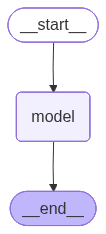

In [5]:
# 可视化 Agent
agent

## 三、带工具调用的 Agent

接下来，我们创建一个带工具调用的 ReAct Agent，它会根据需求自主决定是否调用工具。

In [11]:
"""
如果不是晴天，还会调用这个工具吗？
会，而且和 “实际天气” 无关。
1. 模型什么时候决定调用工具？
只看用户问题语义，不看外面真实天气：
用户问：“what is the weather in sf” → 属于天气查询
模型知道你给了 get_weather 工具 → 一定会调用它
模型不会先去查外面真实天气再决定调不调
2. 工具返回假结果，模型会怎么处理？
模型拿到 It's sunny in sf! → 直接当真的用
最终回答：“It's sunny in sf!” → 和现实相反
3. 一句话总结
调不调用，看问题；返回什么，看工具；真不真实，看工具是不是连真实 API。
"""

# 一个工具函数
def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's sunny in {city}!"

# 创建带工具调用的Agent
tool_agent = create_agent(
    model=llm,# 用哪个大模型（GPT/通义/文心等）
    tools=[get_weather], # 给 AI 配备的工具列表
    system_prompt="You are a helpful assistant", # AI 人设
)

# 运行Agent
response = tool_agent.invoke(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]}
    # {"messages": [{"role": "user", "content": "how are you"}]}
)

response['messages'][-1].content

"It's sunny in San Francisco!"

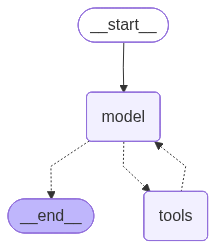

In [12]:
# 可视化 Agent
tool_agent

## 四、使用 `ToolRuntime` 控制工具权限

下面创建一个带 runtime 的工具，runtime 类型为 ToolRuntime。当我们调用 Agent 时，会将这个 runtime 传递给工具。工具再根据 runtime 中的信息，判断当前调用是否具备执行权限。

In [13]:
"""
给 AI 工具加 “权限锁”
管理员（admin）：能用数学加法工具
普通用户（user）：不能用，一用就报错
"""



from typing import Literal, Any
from pydantic import BaseModel
from langchain.tools import tool, ToolRuntime

class Context(BaseModel):
    authority: Literal["admin", "user"]

# 创建带权限控制的tool，依赖ToolRuntime的内容进行判断
@tool # 不加的话，AI 不认识它，不知道这是工具，不会调用它。加上 @tool 后，AI 瞬间认识它了！
def math_add(runtime: ToolRuntime[Context, Any], a: int, b: int) -> int:
    """Add two numbers together."""
    authority = runtime.context.authority
    # 只有admin用户可以访问加法工具
    if authority != "admin":
        raise PermissionError("User does not have permission to add numbers")
    return a + b

# 创建带工具调用的Agent
"""
create_agent 有两种 “工具识别模式”：
普通简单函数 → 自动包装，不用加 @tool
带 runtime/context 的高级函数 → 必须手动加 @tool
"""
tool_agent = create_agent(
    model=llm,
    tools=[get_weather, math_add],
    system_prompt="You are a helpful assistant",
)

# 在运行Agent时注入context
response = tool_agent.invoke(
    {"messages": [{"role": "user", "content": "请计算 8234783 + 94123832 = ?"}]},
    config={"configurable": {"thread_id": "1"}},
    context=Context(authority="admin"),
)

In [14]:
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

请计算 8234783 + 94123832 = ?
================================== Ai Message ==================================
Tool Calls:
  math_add (call_37a5eee4e0874aa98a1b6ed3)
 Call ID: call_37a5eee4e0874aa98a1b6ed3
  Args:
    a: 8234783
    b: 94123832
================================= Tool Message =================================
Name: math_add

102358615
================================== Ai Message ==================================

8234783 + 94123832 = 102358615


In [15]:
# 验证计算结果是否正确
8234783 + 94123832

102358615

## 五、结构化输出

若想获得 [结构化输出](https://docs.langchain.com/oss/python/langchain/structured-output#response-format)（Structured Output），可以在 create_agent 函数的 response_format 参数进行设定。在下面的例子中，我们用 BaseModel 定义输出格式，然后在 response_format 中指定该格式。

> **结构化输出 vs 非结构化输出的区别**：
>
> 代码上只差 `response_format=CalcInfo` 这一行，但输出形式完全不同：
>
> - **非结构化**：返回自然语言文本，如 `"8234783 + 94123832 = 102358615。"`，需要字符串解析才能提取数据，格式不保证。
> - **结构化**：返回符合 schema 的 Pydantic 对象 `CalcInfo(output=102358615)`，可直接 `.output` 取值，适合下游程序消费。

In [16]:
from pydantic import BaseModel, Field

class CalcInfo(BaseModel):
    """Calculation information."""
    output: int = Field(description="The calculation result")

In [17]:
# 创建带结构化输出的Agent
structured_agent = create_agent(
    model=llm,
    tools=[get_weather, math_add],
    system_prompt="You are a helpful assistant",
    response_format=CalcInfo,
)

response = structured_agent.invoke(
    {"messages": [{"role": "user", "content": "请计算 8234783 + 94123832 = ?"}]},
    config={"configurable": {"thread_id": "1"}},
    context=Context(authority="admin"),
)

In [18]:
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

请计算 8234783 + 94123832 = ?
================================== Ai Message ==================================
Tool Calls:
  math_add (call_0a15d7032eeb4ce9a5aababb)
 Call ID: call_0a15d7032eeb4ce9a5aababb
  Args:
    a: 8234783
    b: 94123832
================================= Tool Message =================================
Name: math_add

102358615
================================== Ai Message ==================================
Tool Calls:
  CalcInfo (call_1cb5b0542d01495e896b021b)
 Call ID: call_1cb5b0542d01495e896b021b
  Args:
    output: 102358615
================================= Tool Message =================================
Name: CalcInfo

Returning structured response: output=102358615


In [19]:
response['structured_response']

CalcInfo(output=102358615)

In [20]:
print(response['structured_response'].output)  # 输出 102358615

102358615


## 六、流式输出

**流式输出 vs 普通输出**：
- `invoke()`：等 Agent 全部跑完，一次性返回结果（像等一锅汤熬好再端上来）
- `stream()`：边跑边吐数据，拿到一块就处理一块（像边煲边舀，实时看到进展）

**三种 `stream_mode` 对比**：

| 模式 | 粒度 | 输出内容 | 适用场景 |
|---|---|---|---|
| `updates` | 节点级别 | 每个节点完成后的新增数据 | 监控 Agent 执行流程 |
| `messages` | token 级别 | 逐字生成的内容 | 实时 UI 展示（打字效果） |
| `values` | 全局级别 | 完整的 State 快照 | 调试、检查点、存历史 |

Agent 内部是一个状态图，主要节点有两个：
- **`model`**：调用大模型生成内容或决定调用哪个工具
- **`tools`**：执行工具并返回结果

更多信息请参阅 [streaming](https://docs.langchain.com/oss/python/langchain/streaming/overview).

### 1）`updates` 模式

`stream_mode="updates"`：每个节点完成后流式更新

In [26]:
%autoawait on

"""
天气查询完整流程（节点顺序）
你问：What is the weather in SF?执行顺序就是：
llm 节点LLM 看懂问题 → 判断需要调用天气工具
tools 节点调用 get_weather → 获取结果
llm 节点LLM 把工具返回的天气整理成自然语言
end 节点结束，返回回答
每一步完成，就会通过 stream 推送给你。
"""

agent = create_agent(
    model=llm,
    tools=[get_weather],
)

for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "What is the weather in SF?"}]},
    stream_mode="updates",
):
    for step, data in chunk.items():
        print(f"step: {step}")
        print(f"content: {data['messages'][-1].content_blocks}")

step: model
content: [{'type': 'tool_call', 'name': 'get_weather', 'args': {'city': 'San Francisco'}, 'id': 'call_fbe4617d94584ab5ba4ce874'}]
step: tools
content: [{'type': 'text', 'text': "It's sunny in San Francisco!"}]
step: model
content: [{'type': 'text', 'text': "It's sunny in San Francisco!"}]


### 2）`messages` 模式

`stream_mode="messages"`：每个 token 生成后流式更新

这是最细粒度的模式，模型每生成一个字（token）就吐出来，这就是 ChatGPT 网页上「字一个一个蹦出来」的效果。适合做实时 UI 展示，用户不用干等。

In [28]:
async def agent_invoke():
    content, last_node = "", ""
    display_handle = display("", display_id=True)

    async for token, metadata in agent.astream(  
        {"messages": [{"role": "user", "content": "What is the weather in SF?"}]},
        stream_mode="messages",
    ):
        node = metadata['langgraph_node']
        if last_node and node != last_node:
            content += f"\n\n🔹 <b>node:</b> {node}\n📝 <b>content: </b>"
        if node == 'model' and token.content:
            content += token.content
        elif node == 'tools' and token.content:
            content += token.content

        last_node = node
        update_display(HTML(f"<pre>{content}</pre>"), display_id=display_handle.display_id)

print("打印工具节点和模型节点的输出结果：")
await agent_invoke()

打印工具节点和模型节点的输出结果：


### 3）`values` 模式

`stream_mode="values"`：流式输出 State 的快照

每次节点跑完后，输出当前**整个 Agent 的状态**（全部消息历史）。相当于每个步骤后拍一张「全场照片」，你能看到累积的所有消息。适合调试、存检查点、在 UI 中展示完整对话历史。

In [29]:
async def agent_invoke():
    content, last_node = "", ""

    async for payload in agent.astream(  
        {"messages": [{"role": "user", "content": "What is the weather in SF?"}]},
        stream_mode="messages",
    ):
        state = payload[0]
        if hasattr(state, "tool_calls") and state.tool_calls:
            if state.tool_calls[0].get('name'):
                print("name:", state.tool_calls[0].get('name'))
            if state.tool_calls[0].get('args'):
                print("args:", state.tool_calls[0].get('args'))

print("打印工具调用信息：\n")
await agent_invoke()

打印工具调用信息：

name: get_weather
